# **Actividad 2 - Análisis del proceso de ML supervisado de clasificación binaria de caso práctico**

**Estudiante:** David Alejandro Narvaez Mejia

**Fecha:** 05/03/2025

**Materia:** Aprenizaje Automatico - MIAR0525

**Profesor:** Gladys Villegas R. PhD(C)

**Referencias:**

[1] https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset

[2] Géron, A. (2022). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems (3rd ed.). O'Reilly Media.

In [72]:
# Importación de bibliotecas
# Librerias comunes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

#Librerias de ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

Para tener una breve descripcion del dataset visitar:
https://github.com/DAVOALEJO1987/ACTIVIDAD-2/blob/main/README.md


In [73]:
# Cargar el dataset desde repositorio githu
# La fuente del dataset es:  https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset
df = pd.read_csv("https://raw.githubusercontent.com/DAVOALEJO1987/ACTIVIDAD-2/main/gym_members_exercise_tracking.csv")
print("Primeras 10 filas del dataset:")
df.head(10)

Primeras 10 filas del dataset:


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313,Yoga,12.6,3.5,4,2,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556,Strength,29.2,2.8,3,1,14.39
5,56,Female,58.0,1.68,168,156,74,1.59,1116,HIIT,15.5,2.7,5,2,20.55
6,36,Male,70.3,1.72,174,169,73,1.49,1385,Cardio,21.3,2.3,3,2,23.76
7,40,Female,69.7,1.51,189,141,64,1.27,895,Cardio,30.6,1.9,3,2,30.57
8,28,Male,121.7,1.94,185,127,52,1.03,719,Strength,28.9,2.6,4,2,32.34
9,28,Male,101.8,1.84,169,136,64,1.08,808,Cardio,29.7,2.7,3,1,30.07


In [74]:
# Visualización inicial de los datos
print("\nInformación del dataset:")
df.info()
print("\nTamano del dataset:")
print(df.shape)


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    int64  
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/

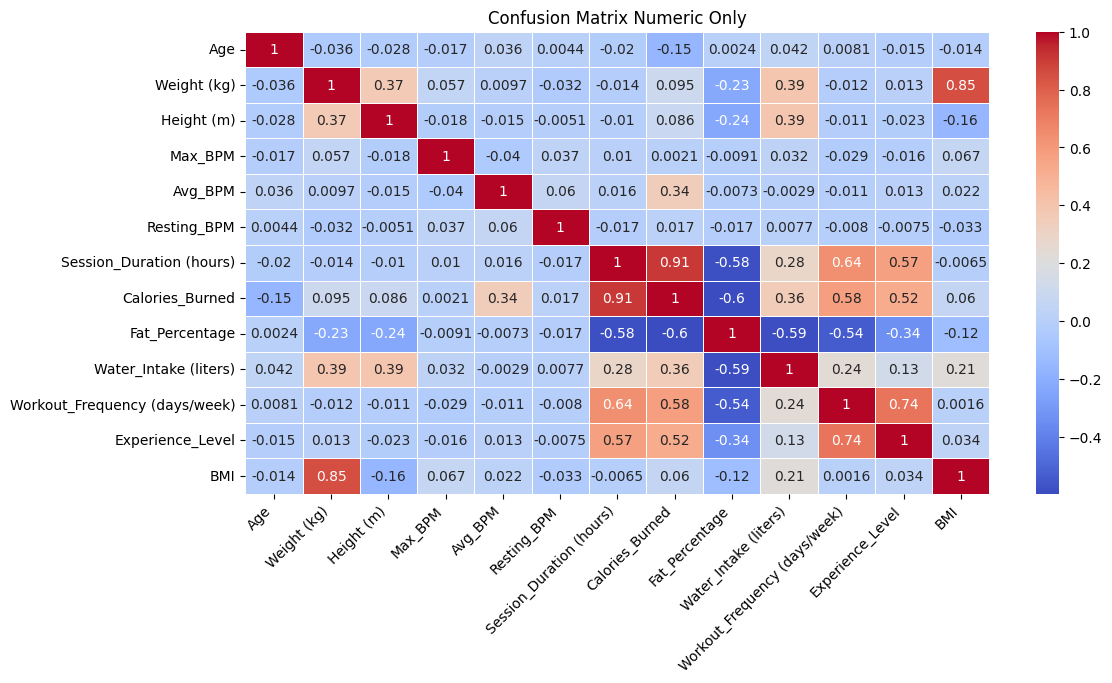

In [75]:
# Analisis EDA
cm = df.corr(numeric_only=True)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Confusion Matrix Numeric Only')
plt.xticks(rotation=45, ha='right')
plt.show()

**Analisis de correlaciones**           
Con base en la matriz de correlación presentada, como analista de datos se identifican las cuatro relaciones más fuertes entre variables numéricas, con un lenguaje técnico:

1.   Calories_Burned y Session_Duration (r = 0.91): Existe una correlación positiva muy fuerte, lo que indica que la duración de las sesiones influye significativamente en la cantidad de calorías quemadas.
2.   Weight y BMI (r = 0.85): Se confirma una relación directa significativa entre el peso corporal y el índice de masa corporal, coherente con su fórmula.
3.   Calories_Burned y Workout_Frequency (r = 0.58): Refleja que un mayor número de sesiones semanales contribuye al gasto calórico.
4.   Experience_Level y Workout_Frequency (r = 0.74): Sugiere que los usuarios más experimentados tienden a entrenar con mayor frecuencia.

Para el análisis de ML de clasificación binaria supervisada escojemos Calories_Burned y Workout_Frequency

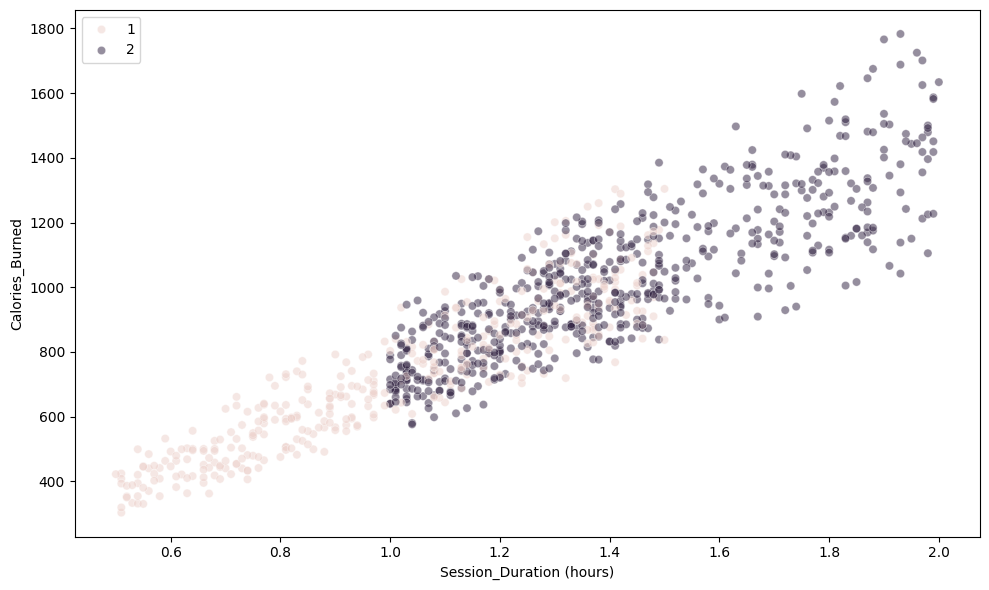

In [76]:
# Analisis ML - Calories_Burned y Workout_Frequency
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x=df['Session_Duration (hours)'], y=df['Calories_Burned'], hue='Experience_Level', alpha=.5)
plt.legend()
plt.tight_layout()
plt.show()

In [77]:
# Preprocesamiento de dataset y limpieza
# Eliminamos columnas que no vamos a utilizar
df.drop(columns=['Age' , 'Weight (kg)', 'Height (m)', 'Max_BPM' , 'Avg_BPM' , 'Resting_BPM' , 'Fat_Percentage', 'Water_Intake (liters)' , 'Workout_Type' , 'BMI' ],inplace=True)

# Si existe la columna 'Gender', la convertimos en numérica
if 'Gender' in df.columns:
    # Convertimos 'Gender' a variable numérica (0: Female, 1: Male)
    df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
    # Selección de características incluyendo 'Gender'
    X = df[['Gender' , 'Session_Duration (hours)' , 'Calories_Burned' , 'Workout_Frequency (days/week)']]

else:
    X = df[['Session_Duration (hours)' , 'Calories_Burned' , 'Workout_Frequency (days/week)']]
#    X = df[['Gender' , 'Session_Duration (hours)' , 'Calories_Burned' , 'Workout_Frequency (days/week)']]

y = df['Experience_Level']
df

,Gender,Session_Duration (hours),Calories_Burned,Workout_Frequency (days/week),Experience_Level
0,1,1.69,1313,4,2
1,0,1.30,883,4,2
2,0,1.11,677,4,2
3,1,0.59,532,3,1
4,1,0.64,556,3,1
...,...,...,...,...,...
968,1,1.57,1364,4,2
969,1,1.38,1260,2,1
970,0,1.72,929,5,2
971,1,1.10,883,3,2


Primeras 10 filas del dataset:
   Gender  Session_Duration (hours)  Calories_Burned  \
0       1                      1.69             1313   
1       0                      1.30              883   
2       0                      1.11              677   
3       1                      0.59              532   
4       1                      0.64              556   
5       0                      1.59             1116   
6       1                      1.49             1385   
7       0                      1.27              895   
8       1                      1.03              719   
9       1                      1.08              808   

   Workout_Frequency (days/week)  Experience_Level  
0                              4                 2  
1                              4                 2  
2                              4                 2  
3                              3                 1  
4                              3                 1  
5                              5  

<Figure size 1200x800 with 0 Axes>

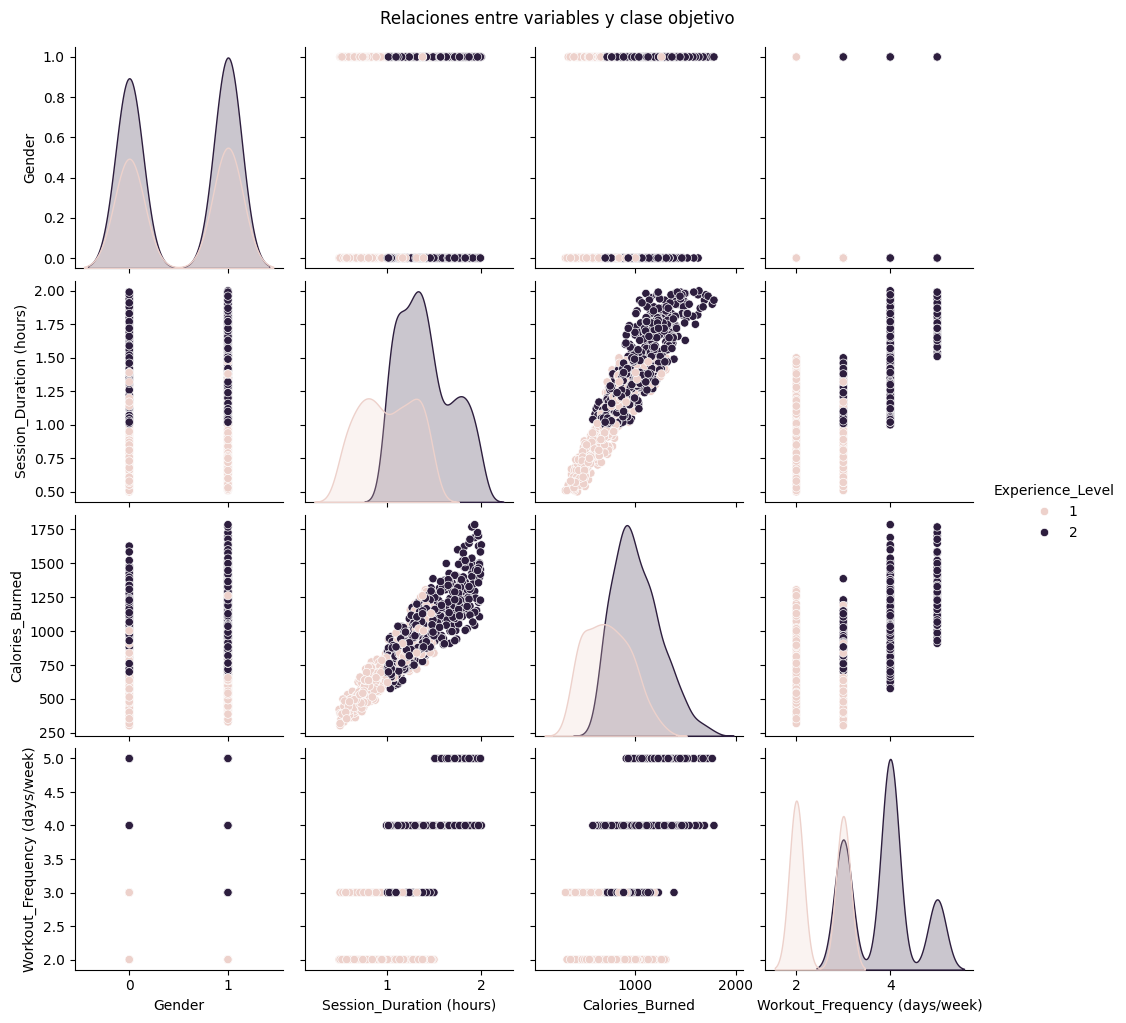

In [79]:
# Estadistica descriptiva de los datos de mayor correlacion
# Visualización inicial de los datos
print("Primeras 10 filas del dataset:")
print(df.head(10))

print("\nInformación del dataset:")
print(df.info())

print("\nEstadísticas descriptivas:")
print(df.describe())

# Visualización de correlaciones
plt.figure(figsize=(12, 8))
sns.pairplot(df, hue='Experience_Level')
plt.suptitle('Relaciones entre variables y clase objetivo', y=1.02)
plt.savefig('pairplot.png')  # Guardar figura para referencia
plt.show()

In [80]:
# Escalado de características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

Tamaño del conjunto de entrenamiento: (729, 4)
Tamaño del conjunto de prueba: (244, 4)


In [81]:
# Modelos Aprendizaje Automatico - ML supervisado de predicción
print("\n" + "="*80)
print("Modelos Aprendizaje Automatico - ML supervisado de predicción")
print("="*80)

# Seleccion de modelos
lr = LogisticRegression(random_state=42)
svm = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)
tree = DecisionTreeClassifier(max_depth=10, random_state=42)
KNE = KNeighborsClassifier(n_neighbors=3)

# Entrenamiento de modelos
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
tree.fit(X_train, y_train)
KNE.fit(X_train, y_train)

# Predicciones
y_pred_lr = lr.predict(X_test)
y_pred_svm = svm.predict(X_test)
y_pred_tree = tree.predict(X_test)
y_pred_KNE = KNE.predict(X_test)

# Prueba vs. predicciones
test = pd.DataFrame(y_test)
test['y_pred_lr'] = y_pred_lr
test['y_pred_svm'] = y_pred_svm
test['y_pred_tree'] = y_pred_tree
test['y_pred_KNE'] = y_pred_KNE
print("\n")
print(test)



Modelos Aprendizaje Automatico - ML supervisado de predicción


     Experience_Level  y_pred_lr  y_pred_svm  y_pred_tree  y_pred_KNE
199                 2          2           2            2           2
538                 2          2           2            2           2
174                 1          2           2            2           2
464                 1          1           1            1           1
66                  2          2           2            2           2
..                ...        ...         ...          ...         ...
334                 2          2           2            2           1
844                 2          2           2            2           2
25                  2          2           2            2           2
84                  2          1           2            2           1
10                  1          1           1            1           1

[244 rows x 5 columns]



MODELO 1: REGRESIÓN LOGÍSTICA

Matriz de Confusión (Regresión Logística):
[[ 84  15]
 [ 14 131]]


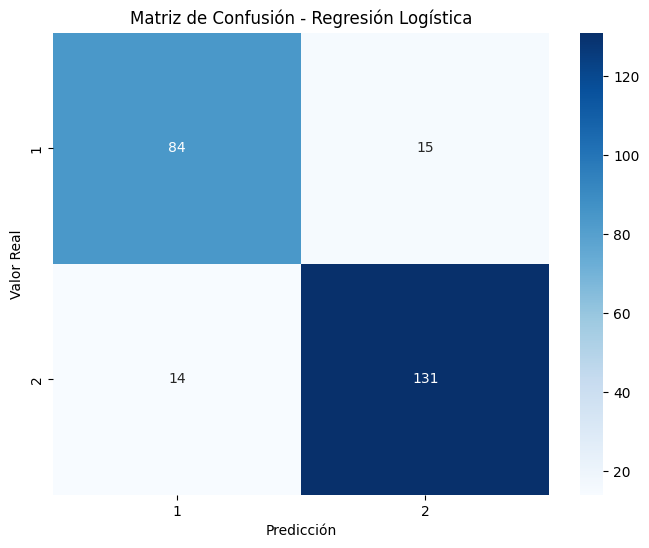

              precision    recall  f1-score   support

           1       0.86      0.85      0.85        99
           2       0.90      0.90      0.90       145

    accuracy                           0.88       244
   macro avg       0.88      0.88      0.88       244
weighted avg       0.88      0.88      0.88       244


MODELO 2: SUPPORT VECTOR MACHINE (SVM)

Matriz de Confusión (SVM):
[[ 77  22]
 [  4 141]]


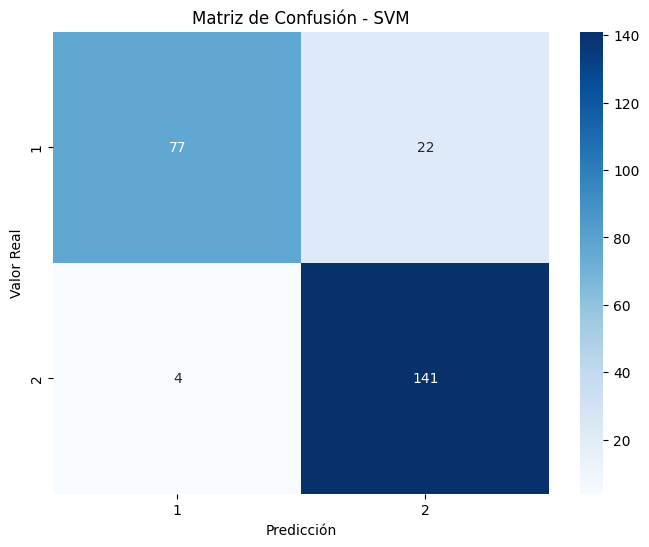


Reporte de Clasificación (SVM):
              precision    recall  f1-score   support

           1       0.95      0.78      0.86        99
           2       0.87      0.97      0.92       145

    accuracy                           0.89       244
   macro avg       0.91      0.88      0.89       244
weighted avg       0.90      0.89      0.89       244


MODELO 3: ÁRBOL DE DECISIÓN

Matriz de Confusión (Árbol de Decisión):
[[ 82  17]
 [  7 138]]


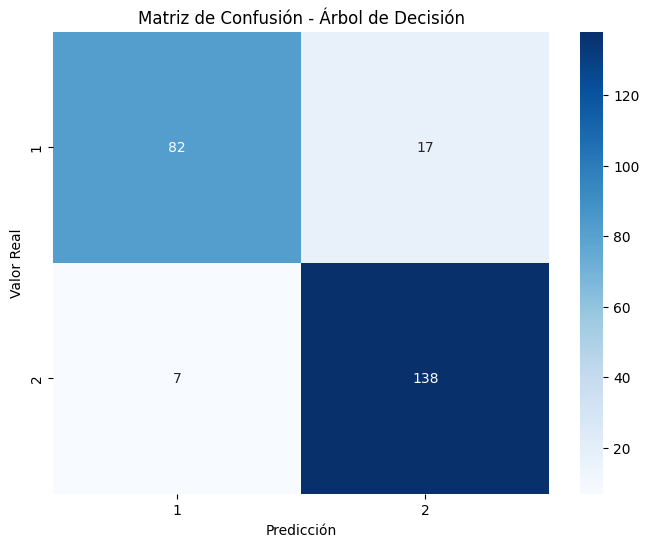


Reporte de Clasificación (Árbol de Decisión):
              precision    recall  f1-score   support

           1       0.92      0.83      0.87        99
           2       0.89      0.95      0.92       145

    accuracy                           0.90       244
   macro avg       0.91      0.89      0.90       244
weighted avg       0.90      0.90      0.90       244


MODELO 4: VECINOS KNE

Matriz de Confusión (Vecinos KNE)):
[[ 85  14]
 [ 13 132]]


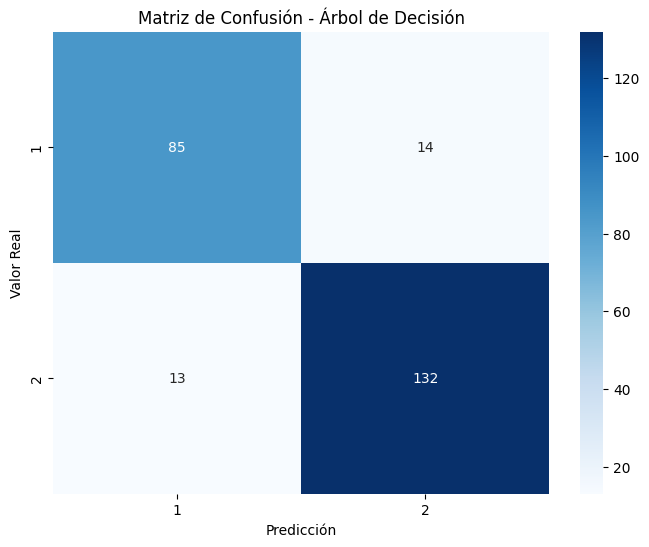


Reporte de Clasificación (Vecinos KNE):
              precision    recall  f1-score   support

           1       0.87      0.86      0.86        99
           2       0.90      0.91      0.91       145

    accuracy                           0.89       244
   macro avg       0.89      0.88      0.89       244
weighted avg       0.89      0.89      0.89       244



In [82]:
# Evaluación - Regresión Logística
print("\n" + "="*50)
print("MODELO 1: REGRESIÓN LOGÍSTICA")
print("="*50)
print("\nMatriz de Confusión (Regresión Logística):")
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
print(conf_matrix_lr)

# Visualización de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['1', '2'],
            yticklabels=['1', '2'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Regresión Logística')
plt.savefig('confusion_matrix_lr.png')
plt.show()

#print("\nReporte de Clasificación (Regresión Logística):")
print(classification_report(y_test, y_pred_lr))

# Evaluación - SVM
print("\n" + "="*50)
print("MODELO 2: SUPPORT VECTOR MACHINE (SVM)")
print("="*50)
print("\nMatriz de Confusión (SVM):")
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
print(conf_matrix_svm)

# Visualización de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['1', '2'],
            yticklabels=['1', '2'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - SVM')
plt.savefig('confusion_matrix_svm.png')
plt.show()

print("\nReporte de Clasificación (SVM):")
print(classification_report(y_test, y_pred_svm))


# Evaluación - Árbol de Decisión
print("\n" + "="*50)
print("MODELO 3: ÁRBOL DE DECISIÓN")
print("="*50)
print("\nMatriz de Confusión (Árbol de Decisión):")
conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)
print(conf_matrix_tree)

# Visualización de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_tree, annot=True, fmt='d', cmap='Blues',
            xticklabels=['1', '2'],
            yticklabels=['1', '2'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.savefig('confusion_matrix_tree.png')
plt.show()

print("\nReporte de Clasificación (Árbol de Decisión):")
print(classification_report(y_test, y_pred_tree))


# Evaluación - Vecinos
print("\n" + "="*50)
print("MODELO 4: VECINOS KNE")
print("="*50)
print("\nMatriz de Confusión (Vecinos KNE)):")
conf_matrix_KNE = confusion_matrix(y_test, y_pred_KNE)
print(conf_matrix_KNE)

# Visualización de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_KNE, annot=True, fmt='d', cmap='Blues',
            xticklabels=['1', '2'],
            yticklabels=['1', '2'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.savefig('confusion_matrix_KNE.png')
plt.show()

print("\nReporte de Clasificación (Vecinos KNE):")
print(classification_report(y_test, y_pred_KNE))



COMPARACIÓN DE MODELOS CON VALIDACIÓN CRUZADA
Regresión Logística: Accuracy promedio = 0.876, Desviación Estándar = 0.054
SVM: Accuracy promedio = 0.898, Desviación Estándar = 0.045
Árbol de Decisión: Accuracy promedio = 0.881, Desviación Estándar = 0.048
Vecinos KNE: Accuracy promedio = 0.880, Desviación Estándar = 0.053

Resumen de validación cruzada:
                Modelo  Accuracy Promedio  Desviación Estándar
0  Regresión Logística           0.875595             0.053971
1                  SVM           0.898342             0.044689
2    Árbol de Decisión           0.880782             0.048104
3          Vecinos KNE           0.879762             0.053199


<ipython-input-88-17b1ee78b250>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='Accuracy Promedio', data=cv_df, palette='viridis')


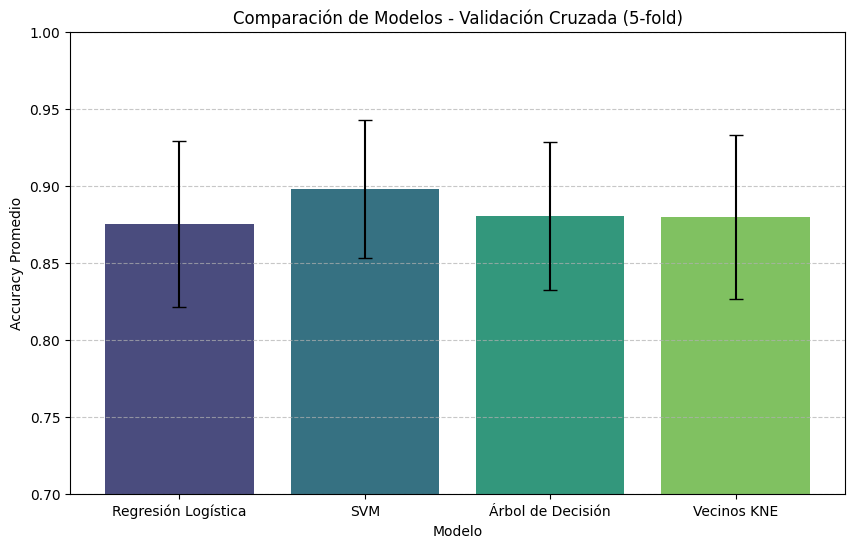

In [88]:
# Comparación de modelos con validación cruzada
print("\n" + "="*50)
print("COMPARACIÓN DE MODELOS CON VALIDACIÓN CRUZADA")
print("="*50)

models = {

     'Regresión Logística': LogisticRegression(random_state=42),
     'SVM': SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42),
     'Árbol de Decisión' : DecisionTreeClassifier(max_depth=10, random_state=42),
     'Vecinos KNE' : KNeighborsClassifier(n_neighbors=3)

}

# Lista para almacenar resultados
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=20, scoring='accuracy')
    cv_results.append({
        'Modelo': name,
        'Accuracy Promedio': scores.mean(),
        'Desviación Estándar': scores.std(),
        'Scores': scores
    })
    print(f"{name}: Accuracy promedio = {scores.mean():.3f}, Desviación Estándar = {scores.std():.3f}")

# Visualización de resultados de validación cruzada
cv_df = pd.DataFrame(cv_results)[['Modelo', 'Accuracy Promedio', 'Desviación Estándar']]
print("\nResumen de validación cruzada:")
print(cv_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='Accuracy Promedio', data=cv_df, palette='viridis')
plt.errorbar(x=range(len(cv_df)), y=cv_df['Accuracy Promedio'],
             yerr=cv_df['Desviación Estándar'], fmt='none', color='black', capsize=5)
plt.title('Comparación de Modelos - Validación Cruzada (5-fold)')
plt.ylim(0.7, 1.0)  # Ajustar según los resultados
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('cross_validation_comparison.png')
plt.show()

In [119]:
# Modelos Aprendizaje Automatico - ML supervisado de predicción
print("\n" + "="*80)
print("Modelos Aprendizaje Automatico - ML supervisado de predicción")
print("="*80)

# Seleccion de modelos
lr = LogisticRegression(random_state=42)
svm = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)
tree = DecisionTreeClassifier(max_depth=10, random_state=42)
KNE = KNeighborsClassifier(n_neighbors=3)

# Entrenamiento de modelos
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
tree.fit(X_train, y_train)
KNE.fit(X_train, y_train)

X_train

# Predicciones
X_object = np.array([ 9.50846775e-01,  1.04316542e-02,  8.65228475e-02, 7.43295089e-01])  # Valores de prueba
# Reshape X_object to a 2D array with one row and multiple columns
X_object = X_object.reshape(1, -1)  # -1 infers the number of columns

y_pred_lr2 = lr.predict(X_object)
y_pred_svm2 = svm.predict(X_object)
y_pred_tree2 = tree.predict(X_object)
y_pred_KNE2 = KNE.predict(X_object)

print('Es un experto nivel, segun Lr', y_pred_lr2)
print('Es un experto nivel, segun SVM', y_pred_svm2)
print('Es un experto nivel, segun Tree', y_pred_tree2)
print('Es un experto nivel, segun vecinos', y_pred_KNE2)


Modelos Aprendizaje Automatico - ML supervisado de predicción
Es un experto nivel, segun Lr [2]
Es un experto nivel, segun SVM [2]
Es un experto nivel, segun Tree [2]
Es un experto nivel, segun vecinos [2]
